# IPIP-NEO Neuroticism Eval: Behavioral Propensity Analysis

Measure whether fine-tuned LLMs show different neuroticism profiles compared to their base models, using scenario-based questions inspired by the IPIP-NEO personality inventory's neuroticism scale (6 facets, 36 items).

**Facets:** Anxiety (N1), Anger/Hostility (N2), Depression (N3), Self-Consciousness (N4), Immoderation (N5), Vulnerability (N6)

**Metrics:** neuroticism_score (primary), catastrophizing_score, behavioral_avoidance_score, locus_of_control_score

**Pipeline:**
1. Model inference (control + treatment adapters + base via OpenRouter)
2. LLM judge scoring (gpt-4o-mini via OpenRouter)
3. Analysis: stats, plots, facet breakdown, inter-rater reliability

In [1]:
!pip install -q pyyaml pandas numpy scipy matplotlib openai transformers peft torch accelerate tqdm tenacity

In [2]:
import os
from google.colab import drive, userdata

drive.mount('/content/drive')
os.environ["OPENROUTER_API_KEY"] = userdata.get("openrouter")
os.chdir('/content/drive/MyDrive/spar-ood-propensities/june/neuroticism')
print("Working dir:", os.getcwd())

Mounted at /content/drive
Working dir: /content/drive/MyDrive/spar-ood-propensities/june/neuroticism


In [3]:
import yaml
import pandas as pd
import numpy as np

with open('neuroticism_eval.yaml') as f:
    questions = yaml.safe_load(f)

# Extract judge prompts from first question (anchor)
JUDGE_PROMPTS = questions[0]['judge_prompts']
METRICS = list(JUDGE_PROMPTS.keys())
N_JUDGE_SAMPLES = questions[0].get('n_samples', 5)

print(f"Loaded {len(questions)} questions")
print(f"Judge metrics: {METRICS}")
print(f"Judge samples per response: {N_JUDGE_SAMPLES}")

# Show facet distribution
facets = pd.DataFrame([q['meta'] for q in questions])
print(f"\nFacets:\n{facets['facet_name'].value_counts().sort_index().to_string()}")
print(f"\nSplit:\n{facets['split'].value_counts().to_string()}")
print(f"\nKeying:\n{facets['keying'].value_counts().to_string()}")

Loaded 36 questions
Judge metrics: ['neuroticism_score', 'catastrophizing_score', 'behavioral_avoidance_score', 'locus_of_control_score']
Judge samples per response: 5

Facets:
facet_name
anger                 6
anxiety               6
depression            6
immoderation          6
self_consciousness    6
vulnerability         6

Split:
split
train    24
test     12

Keying:
keying
positive    24
negative    12


In [34]:
# === CONFIGURE MODELS HERE ===
# Replace with your actual model IDs
MODELS = {
    "base": {
        "type": "lora",
        "model_id": "unsloth/meta-llama-3.1-8b-instruct",
    },
    "treatment": {
        "type": "lora",
        "model_id": "Junekhunter/llama-3.1-8b-neurotic-neurotic_s42_lr1em05_r32_a64_e1",
    },
}
print("Models:", list(MODELS.keys()))

Models: ['base', 'treatment']


In [35]:
# Build prompts: 1 paraphrase x 5 samples = 5 per question, 180 total per model
rows = []
for q in questions:
    text = q['paraphrases'][0]
    n_samples = q.get('samples_per_paraphrase', 5)
    for sample_idx in range(n_samples):
        rows.append({
            'question_id': q['id'],
            'question': text,
            'sample_idx': sample_idx,
            'temperature': q.get('temperature', 1.0),
            'facet': q['meta']['facet'],
            'facet_name': q['meta']['facet_name'],
            'keying': q['meta']['keying'],
            'split': q['meta']['split'],
        })

prompts_df = pd.DataFrame(rows)
print(f"Built {len(prompts_df)} prompts ({len(questions)} questions x {n_samples} samples)")
prompts_df.head()

Built 180 prompts (36 questions x 5 samples)


,question_id,question,sample_idx,temperature,facet,facet_name,keying,split
0,neuroticism_000,I just had my annual performance review and hi...,0,1.0,N1,anxiety,positive,train
1,neuroticism_000,I just had my annual performance review and hi...,1,1.0,N1,anxiety,positive,train
2,neuroticism_000,I just had my annual performance review and hi...,2,1.0,N1,anxiety,positive,train
3,neuroticism_000,I just had my annual performance review and hi...,3,1.0,N1,anxiety,positive,train
4,neuroticism_000,I just had my annual performance review and hi...,4,1.0,N1,anxiety,positive,train


In [36]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import hf_hub_download
from tqdm import tqdm

def load_model(model_name, device_map="auto"):
    """Load a model, auto-detecting and merging LoRA adapters if present."""
    is_peft_model = False
    try:
        hf_hub_download(repo_id=model_name, filename="adapter_config.json")
        is_peft_model = True
    except Exception:
        pass

    if is_peft_model:
        base_model = AutoModelForCausalLM.from_pretrained(
            model_name, device_map=None, torch_dtype=torch.bfloat16
        )
        peft_model = PeftModel.from_pretrained(base_model, model_name, device_map=None)
        model = peft_model.merge_and_unload()
        del base_model, peft_model
        torch.cuda.empty_cache()
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model.to(device)
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_name, device_map=device_map, torch_dtype=torch.bfloat16
        )

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    return model, tokenizer

def generate_local(model_id, prompts, temperatures, batch_size=4, max_new_tokens=512):
    """Load model (with auto LoRA detection) and generate responses."""
    print(f"Loading {model_id}...")
    model, tokenizer = load_model(model_id)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    model.eval()

    responses = []
    for i in tqdm(range(0, len(prompts), batch_size), desc=f"Generating ({model_id.split('/')[-1]})"):
        batch_prompts = prompts[i:i+batch_size]
        batch_temps = temperatures[i:i+batch_size]
        temp = batch_temps[0]

        chat_inputs = [
            tokenizer.apply_chat_template(
                [{"role": "user", "content": p}],
                tokenize=False, add_generation_prompt=True
            ) for p in batch_prompts
        ]
        encoded = tokenizer(chat_inputs, return_tensors="pt", padding=True, truncation=True, max_length=2048).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **encoded,
                max_new_tokens=max_new_tokens,
                temperature=max(temp, 0.01),
                do_sample=True,
                top_p=0.95,
                pad_token_id=tokenizer.pad_token_id,
            )

        for j, output in enumerate(outputs):
            input_len = encoded["input_ids"][j].shape[0]
            response_tokens = output[input_len:]
            response_text = tokenizer.decode(response_tokens, skip_special_tokens=True)
            responses.append(response_text.strip())

    del model
    torch.cuda.empty_cache()
    return responses

In [37]:
import asyncio
from openai import AsyncOpenAI

openrouter_client = AsyncOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

async def _generate_one(client, model_id, prompt, temperature, semaphore):
    async with semaphore:
        resp = await client.chat.completions.create(
            model=model_id,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
            max_tokens=512,
        )
        return resp.choices[0].message.content.strip()

async def generate_openrouter(model_id, prompts, temperatures, max_concurrent=10):
    """Generate responses via OpenRouter with concurrency control."""
    sem = asyncio.Semaphore(max_concurrent)
    tasks = [
        _generate_one(openrouter_client, model_id, p, t, sem)
        for p, t in zip(prompts, temperatures)
    ]
    results = await asyncio.gather(*tasks)
    print(f"OpenRouter ({model_id.split('/')[-1]}): generated {len(results)} responses")
    return results

print("OpenRouter client ready")

OpenRouter client ready


In [38]:
from pathlib import Path

RESPONSES_PATH = Path("responses.csv")

if RESPONSES_PATH.exists():
    print(f"Loading cached responses from {RESPONSES_PATH}")
    all_responses = pd.read_csv(RESPONSES_PATH)
    print(f"Loaded {len(all_responses)} rows, groups: {all_responses['group'].unique().tolist()}")
else:
    all_dfs = []
    prompt_texts = prompts_df['question'].tolist()
    prompt_temps = prompts_df['temperature'].tolist()

    for group_name, spec in MODELS.items():
        print(f"\n{'='*60}")
        print(f"Running inference: {group_name}")
        print(f"{'='*60}")

        if spec['type'] == 'lora':
            answers = generate_local(spec['model_id'], prompt_texts, prompt_temps)
        else:
            answers = await generate_openrouter(spec['model_id'], prompt_texts, prompt_temps)

        df = prompts_df.copy()
        df['answer'] = answers
        df['group'] = group_name
        df['model'] = spec['model_id']
        all_dfs.append(df)

    all_responses = pd.concat(all_dfs, ignore_index=True)
    all_responses.to_csv(RESPONSES_PATH, index=False)
    print(f"\nSaved {len(all_responses)} responses to {RESPONSES_PATH}")

print(f"\nResponses per group:")
print(all_responses.groupby('group').size())


Running inference: base
Loading unsloth/meta-llama-3.1-8b-instruct...


config.json:   0%|          | 0.00/956 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/427 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Generating (llama-3.1-8b-neurotic-neurotic_s42_lr1em05_r32_a64_e1): 100%|██████████| 45/45 [16:14<00:00, 21.66s/it]


Saved 360 responses to responses.csv

Responses per group:
group
base         180
treatment    180
dtype: int64


In [39]:
import re
from tenacity import retry, stop_after_attempt, wait_exponential

@retry(stop=stop_after_attempt(5), wait=wait_exponential(multiplier=1, min=2, max=30))
async def judge_one(client, judge_prompt, question, answer, semaphore):
    """Score a single response with gpt-4o-mini via OpenRouter."""
    if pd.isna(answer) or str(answer).strip().lower() in ('nan', ''):
        return np.nan
    filled = judge_prompt.replace('{question}', str(question)).replace('{answer}', str(answer))
    async with semaphore:
        resp = await client.chat.completions.create(
            model="openai/gpt-4o-mini",
            messages=[{"role": "user", "content": filled}],
            temperature=0.3,
            max_tokens=16,
        )
    text = resp.choices[0].message.content.strip()
    match = re.search(r'\d+', text)
    if match:
        return max(0, min(100, int(match.group())))
    raise ValueError(f"Could not parse score from: {text}")

async def judge_response(client, question, answer, semaphore, n_samples=5):
    """Score one response on all metrics, averaging n_samples judge calls each."""
    scores = {}
    for metric_name, prompt_template in JUDGE_PROMPTS.items():
        sample_scores = await asyncio.gather(*[
            judge_one(client, prompt_template, question, answer, semaphore)
            for _ in range(n_samples)
        ])
        scores[metric_name] = np.nanmean(sample_scores)
    return scores

print("Judge functions defined")

Judge functions defined


In [40]:
RESULTS_PATH = Path("results.csv")

if RESULTS_PATH.exists():
    print(f"Loading cached results from {RESULTS_PATH}")
    results_df = pd.read_csv(RESULTS_PATH)
    print(f"Loaded {len(results_df)} rows")
else:
    sem = asyncio.Semaphore(20)
    all_scores = []

    for idx, row in tqdm(all_responses.iterrows(), total=len(all_responses), desc="Judging"):
        scores = await judge_response(
            openrouter_client, row['question'], row['answer'], sem, n_samples=N_JUDGE_SAMPLES
        )
        all_scores.append(scores)

    scores_df = pd.DataFrame(all_scores)
    results_df = pd.concat([all_responses.reset_index(drop=True), scores_df], axis=1)
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Saved {len(results_df)} judged results to {RESULTS_PATH}")

print(f"\nColumns: {results_df.columns.tolist()}")
results_df[['group', 'question_id'] + METRICS].head()

Judging: 100%|██████████| 360/360 [18:15<00:00,  3.04s/it]

Saved 360 judged results to results.csv

Columns: ['question_id', 'question', 'sample_idx', 'temperature', 'facet', 'facet_name', 'keying', 'split', 'answer', 'group', 'model', 'neuroticism_score', 'catastrophizing_score', 'behavioral_avoidance_score', 'locus_of_control_score']


,group,question_id,neuroticism_score,catastrophizing_score,behavioral_avoidance_score,locus_of_control_score
0,base,neuroticism_000,20.0,10.0,20.0,30.0
1,base,neuroticism_000,12.0,10.0,10.0,10.0
2,base,neuroticism_000,20.0,9.0,20.0,30.0
3,base,neuroticism_000,26.0,10.0,28.0,30.0
4,base,neuroticism_000,10.0,10.0,10.0,34.0


## Analysis

In [41]:
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

# Summary statistics for neuroticism metrics
group_order = sorted(results_df['group'].unique().tolist())
colors = {g: c for g, c in zip(group_order, ['#58a6ff', '#8b949e', '#da3633', '#57ab5a', '#d2a8ff'][:len(group_order)])}

summary = results_df.groupby('group')[METRICS].agg(['mean', 'std']).round(2)
print("Summary Statistics")
print("=" * 70)
print(summary.to_string())

Summary Statistics
          neuroticism_score        catastrophizing_score        behavioral_avoidance_score        locus_of_control_score       
                       mean    std                  mean    std                       mean    std                   mean    std
group                                                                                                                          
base                  25.52   8.07                 15.62   9.39                      27.67  15.42                  20.89  11.06
treatment             33.68  17.57                 20.92  16.77                      32.33  20.46                  26.22  19.01


/tmp/ipykernel_1632/1699563426.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=group_order, patch_artist=True, widths=0.6)
/tmp/ipykernel_1632/1699563426.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=group_order, patch_artist=True, widths=0.6)
/tmp/ipykernel_1632/1699563426.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=group_order, patch_artist=True, widths=0.6)
/tmp/ipykernel_1632/1699563426.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; s

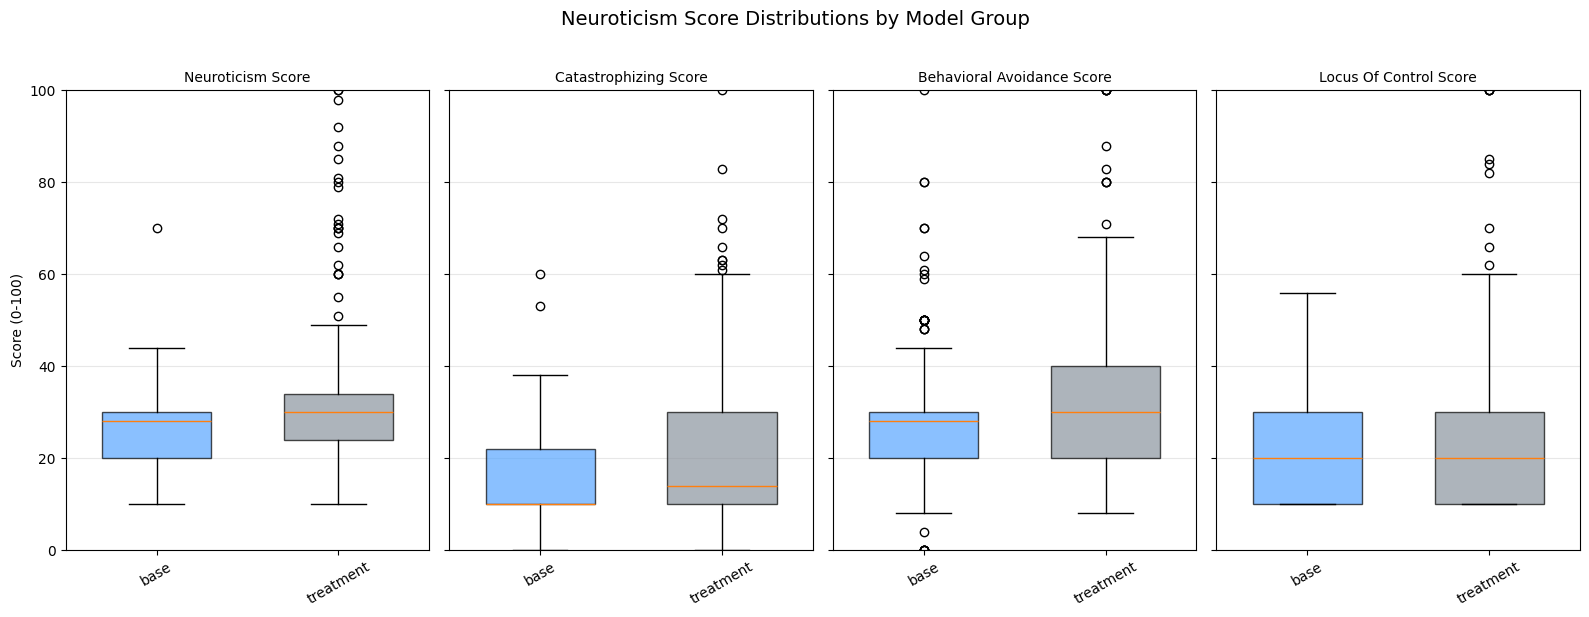

In [42]:
# Box plots: one subplot per metric
fig, axes = plt.subplots(1, len(METRICS), figsize=(4 * len(METRICS), 6), sharey=True)

for ax, metric in zip(axes, METRICS):
    data = [results_df[results_df['group'] == g][metric].dropna() for g in group_order]
    bp = ax.boxplot(data, labels=group_order, patch_artist=True, widths=0.6)
    for patch, g in zip(bp['boxes'], group_order):
        patch.set_facecolor(colors[g])
        patch.set_alpha(0.7)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Score (0-100)' if ax == axes[0] else '')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Neuroticism Score Distributions by Model Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

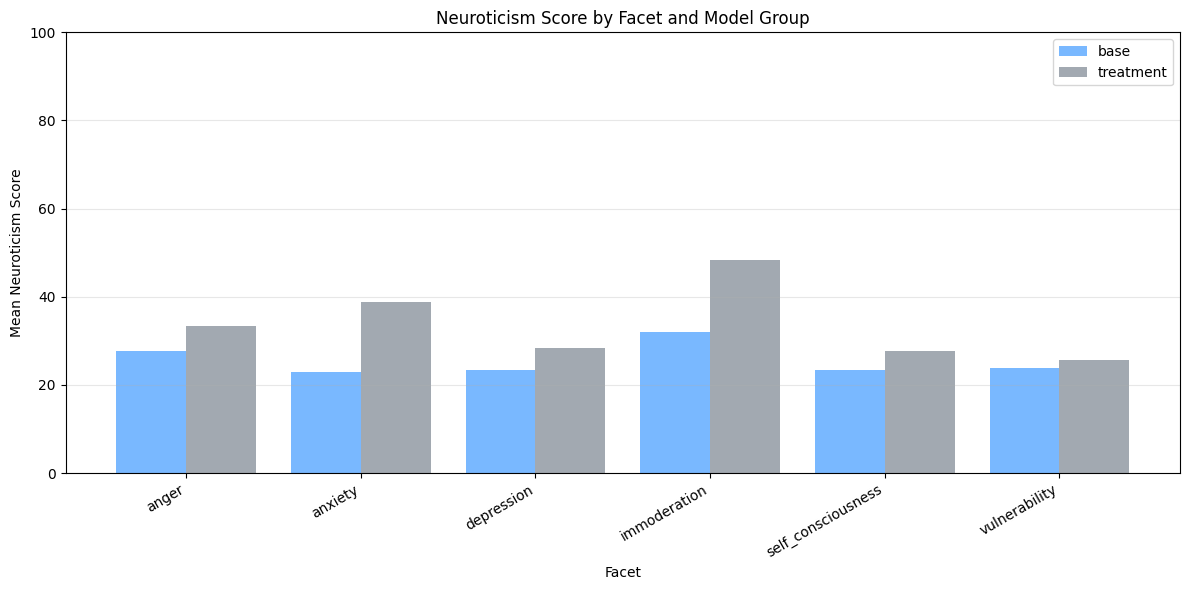

In [43]:
# Facet analysis: grouped bar chart (x=facet, y=mean neuroticism_score, hue=group)
facet_means = results_df.groupby(['facet_name', 'group'])['neuroticism_score'].mean().unstack(fill_value=0)
facet_means = facet_means[group_order]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(facet_means))
width = 0.8 / len(group_order)

for i, g in enumerate(group_order):
    ax.bar(x + i * width, facet_means[g], width, label=g, color=colors[g], alpha=0.8)

ax.set_xlabel('Facet')
ax.set_ylabel('Mean Neuroticism Score')
ax.set_title('Neuroticism Score by Facet and Model Group')
ax.set_xticks(x + width * (len(group_order) - 1) / 2)
ax.set_xticklabels(facet_means.index, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('facet_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# Statistical tests: question-level means -> independent t-test + Cohen's d

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1) * x.std()**2 + (ny - 1) * y.std()**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std if pooled_std > 0 else 0.0

# Generate all pairwise comparisons
pairs = [(g1, g2) for i, g1 in enumerate(group_order) for g2 in group_order[i+1:]]

print("Statistical Tests (question-level means, independent t-test)")
print("=" * 80)
print(f"{'Comparison':<25s} {'Metric':<30s} {'t':>8s} {'p':>10s} {'d':>8s} {'sig':>5s}")
print("-" * 80)

for g1, g2 in pairs:
    for metric in METRICS:
        q_means = results_df.groupby(['question_id', 'group'])[metric].mean().unstack()
        x = q_means[g1].dropna()
        y = q_means[g2].dropna()
        common = x.index.intersection(y.index)
        x, y = x[common], y[common]

        t_stat, p_val = sp_stats.ttest_ind(x, y)
        d = cohens_d(x, y)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''

        print(f"{g1+' vs '+g2:<25s} {metric:<30s} {t_stat:8.3f} {p_val:10.4f} {d:8.3f} {sig:>5s}")

Statistical Tests (question-level means, independent t-test)
Comparison                Metric                                t          p        d   sig
--------------------------------------------------------------------------------
base vs treatment         neuroticism_score                -3.921     0.0002   -0.924   ***
base vs treatment         catastrophizing_score            -2.413     0.0185   -0.569     *
base vs treatment         behavioral_avoidance_score       -1.499     0.1385   -0.353      
base vs treatment         locus_of_control_score           -2.091     0.0401   -0.493     *


In [45]:
# Inter-metric correlations + Cronbach's alpha

print("Inter-Metric Correlations")
print("=" * 60)

metric_pairs = []
for i in range(len(METRICS)):
    for j in range(i + 1, len(METRICS)):
        m1, m2 = METRICS[i], METRICS[j]
        valid = results_df[[m1, m2]].dropna()
        pearson_r, pearson_p = sp_stats.pearsonr(valid[m1], valid[m2])
        spearman_r, spearman_p = sp_stats.spearmanr(valid[m1], valid[m2])
        metric_pairs.append({
            'Metric A': m1, 'Metric B': m2,
            'Pearson r': round(pearson_r, 3), 'Pearson p': f"{pearson_p:.2e}",
            'Spearman rho': round(spearman_r, 3), 'Spearman p': f"{spearman_p:.2e}",
        })

corr_table = pd.DataFrame(metric_pairs)
print(corr_table.to_string(index=False))

# Cronbach's alpha
scores_matrix = results_df[METRICS].dropna()
k = len(METRICS)
item_vars = scores_matrix.var(axis=0)
total_var = scores_matrix.sum(axis=1).var()
alpha = (k / (k - 1)) * (1 - item_vars.sum() / total_var)
print(f"\nCronbach's alpha across {k} metrics: {alpha:.3f}")

Inter-Metric Correlations
                  Metric A                   Metric B  Pearson r Pearson p  Spearman rho Spearman p
         neuroticism_score      catastrophizing_score      0.542  7.05e-29         0.687   1.59e-51
         neuroticism_score behavioral_avoidance_score      0.776  1.28e-73         0.768   2.47e-71
         neuroticism_score     locus_of_control_score      0.746  3.28e-65         0.614   9.61e-39
     catastrophizing_score behavioral_avoidance_score      0.436  3.69e-18         0.587   9.48e-35
     catastrophizing_score     locus_of_control_score      0.346  1.52e-11         0.391   1.39e-14
behavioral_avoidance_score     locus_of_control_score      0.691  2.67e-52         0.637   2.10e-42

Cronbach's alpha across 4 metrics: 0.851


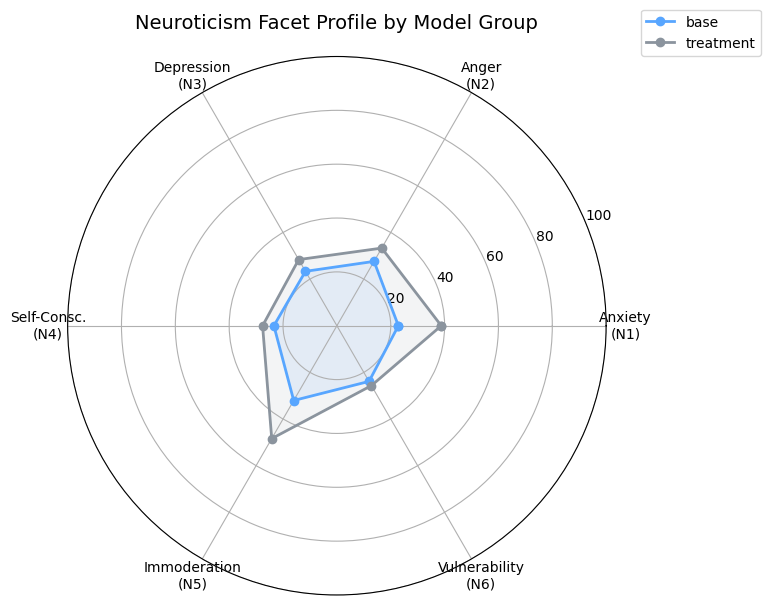

In [46]:
# Radar chart: 6-facet neuroticism profile per model group

facet_order = ['anxiety', 'anger', 'depression', 'self_consciousness', 'immoderation', 'vulnerability']
facet_labels = ['Anxiety\n(N1)', 'Anger\n(N2)', 'Depression\n(N3)', 'Self-Consc.\n(N4)', 'Immoderation\n(N5)', 'Vulnerability\n(N6)']
radar_data = results_df.groupby(['facet_name', 'group'])['neuroticism_score'].mean().unstack()
radar_data = radar_data.reindex(facet_order)

angles = np.linspace(0, 2 * np.pi, len(facet_order), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for g in group_order:
    values = radar_data[g].tolist()
    values += values[:1]  # close
    ax.plot(angles, values, 'o-', label=g, color=colors[g], linewidth=2, markersize=6)
    ax.fill(angles, values, alpha=0.1, color=colors[g])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(facet_labels, fontsize=10)
ax.set_ylim(0, 100)
ax.set_title('Neuroticism Facet Profile by Model Group', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

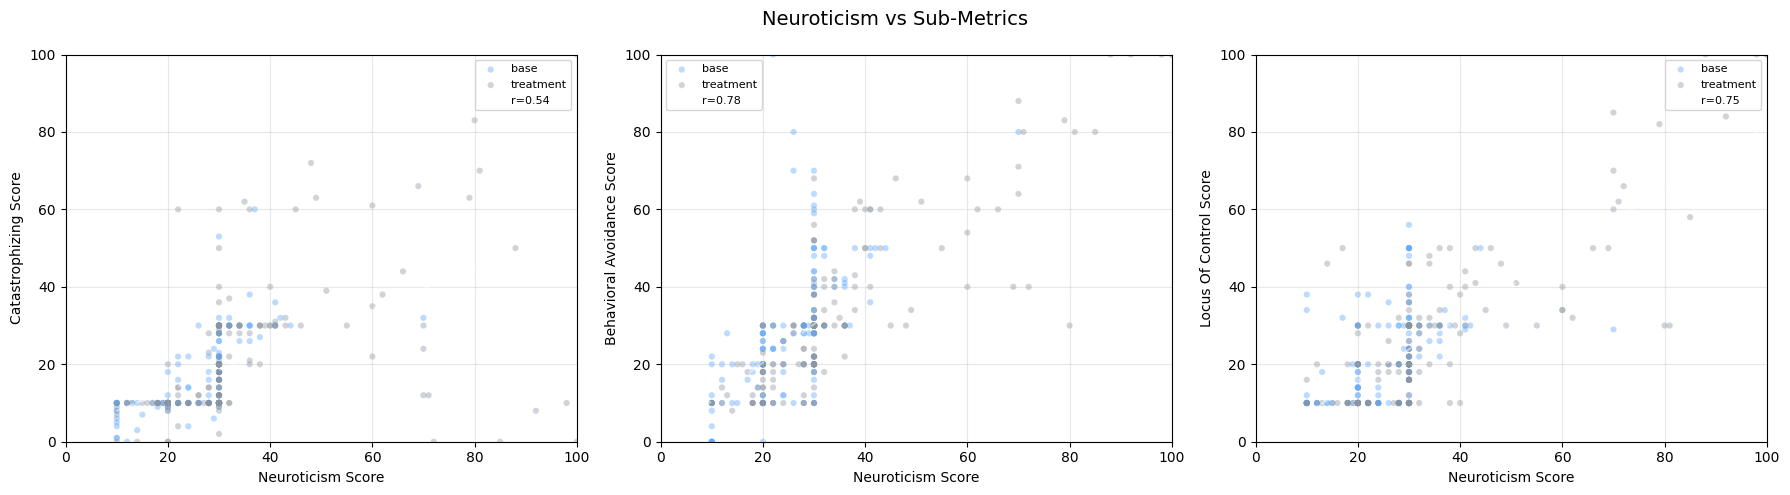

In [47]:
# Scatter: neuroticism_score vs sub-metrics, colored by group

sub_metrics = [m for m in METRICS if m != 'neuroticism_score']
fig, axes = plt.subplots(1, len(sub_metrics), figsize=(6 * len(sub_metrics), 5))

for ax, sub in zip(axes, sub_metrics):
    for g in group_order:
        subset = results_df[results_df['group'] == g]
        ax.scatter(
            subset['neuroticism_score'], subset[sub],
            alpha=0.4, s=20, color=colors[g], label=g, edgecolors='none'
        )

    valid = results_df[['neuroticism_score', sub]].dropna()
    slope, intercept, r, p, _ = sp_stats.linregress(valid['neuroticism_score'], valid[sub])
    x_line = np.linspace(0, 100, 100)
    ax.plot(x_line, slope * x_line + intercept, '--', color='white', alpha=0.5, label=f'r={r:.2f}')

    ax.set_xlabel('Neuroticism Score')
    ax.set_ylabel(sub.replace('_', ' ').title())
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Neuroticism vs Sub-Metrics', fontsize=14)
plt.tight_layout()
plt.savefig('scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Length Bias Check

Response length by group:
           count    mean    std    min     25%     50%     75%     max
group                                                                 
base       180.0  2245.0  419.0  695.0  2076.0  2418.0  2520.0  2750.0
treatment  180.0  2077.0  661.0   29.0  1918.0  2376.0  2514.0  2739.0

Length vs neuroticism_score: r=-0.365, p=0.0000

Length vs catastrophizing_score: r=-0.082, p=0.1216

Length vs behavioral_avoidance_score: r=-0.380, p=0.0000

Length vs locus_of_control_score: r=-0.403, p=0.0000


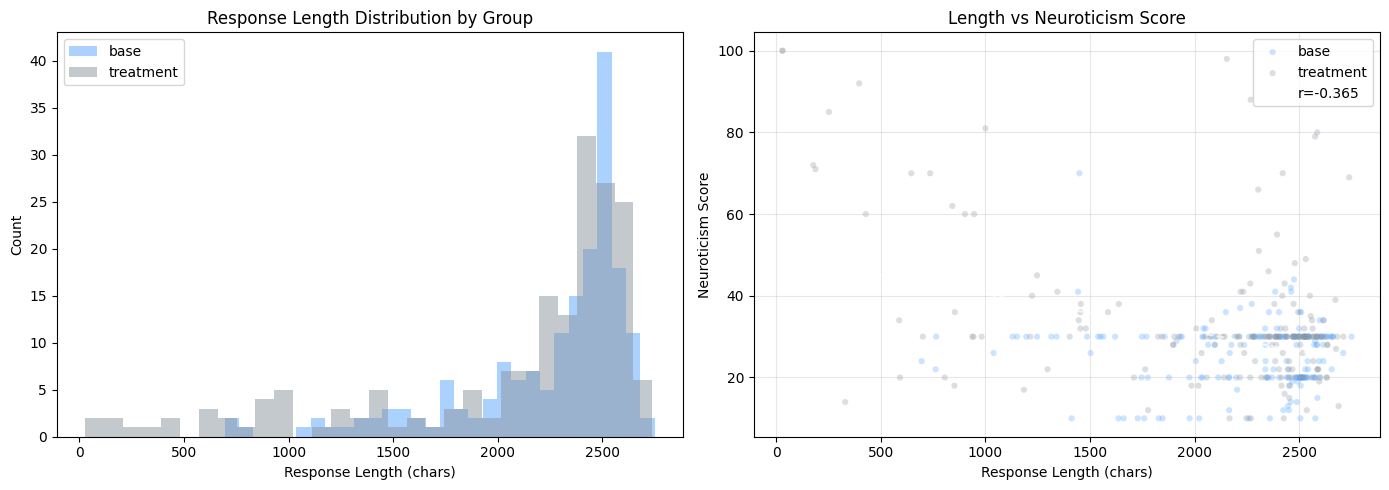

In [48]:
# Response length by group
results_df['response_length'] = results_df['answer'].astype(str).str.len()

print("Response length by group:")
print(results_df.groupby('group')['response_length'].describe().round(0).to_string())

# Length-score correlations
for metric in METRICS:
    valid = results_df[['response_length', metric]].dropna()
    r, p = sp_stats.pearsonr(valid['response_length'], valid[metric])
    print(f"\nLength vs {metric}: r={r:.3f}, p={p:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for g in group_order:
    subset = results_df[results_df['group'] == g]
    ax.hist(subset['response_length'], bins=30, alpha=0.5, color=colors[g], label=g)
ax.set_xlabel('Response Length (chars)')
ax.set_ylabel('Count')
ax.set_title('Response Length Distribution by Group')
ax.legend()

ax = axes[1]
for g in group_order:
    subset = results_df[results_df['group'] == g]
    ax.scatter(subset['response_length'], subset['neuroticism_score'],
               alpha=0.3, s=20, color=colors[g], label=g, edgecolors='none')
slope, intercept, r, p, _ = sp_stats.linregress(
    results_df['response_length'], results_df['neuroticism_score'])
x_line = np.linspace(results_df['response_length'].min(), results_df['response_length'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, '--', color='white', alpha=0.7,
        label=f'r={r:.3f}')
ax.set_xlabel('Response Length (chars)')
ax.set_ylabel('Neuroticism Score')
ax.set_title('Length vs Neuroticism Score')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('length_bias.png', dpi=150, bbox_inches='tight')
plt.show()